# day 15 | 251001 W

## hitherto

We need to clean up some things from last time (see my email about this to you all). Then we will turn to differentiation, while we also work on some above average homework problems. 

## herein

We have been talking about how to do calculus, in particular the integral up till now. But how do we do the derivative? First of all, the calculus itself is nothing other than operations to find either the slope of a function (derivative) or the area under the curve of a function (integral). We often times lose track of what we are actually trying to do when we do this algebraically, so I think it is important to encounter the computational side of things to more fully grasp what is going on.

First off, numerically doing derivatives is very simple, but it is not often done using computers for this reason. If you can do them in your head then why use a computer? But, this is not true for integrals! There are many integrals that do not have a closed form, algebraic solution; so computational methods are necessary to evaluate them. There are also problems with calculating derivatives as we will see, and so they are less used. 

But, first of all we have the definition of the derivative from calculus class
$$\frac{df}{dx} = \lim_{h \rightarrow 0}\frac{f(x+h)-f(x)}{h}$$
And we can do this, just fine except that we cannot divide by zero. But we can make `h` small and maybe that is good enough. 
$$\frac{df}{dx} \approx \frac{f(x+h)-f(x)}{h}$$
This is an approximation that is known as the *forward difference*. And so naturally there is such a thing as the *backward difference*:
$$\frac{df}{dx} \approx \frac{f(x) - f(x-h)}{h}$$

Unfortunately, both of these methods have significant errors. Fortunately, they miss the true value in opposite directions. So we can simply *average* them and get a great approximation. This is known as the *central difference* or *mean finite difference* operator:
$$\frac{df}{dx} \approx \frac{f(x+h)-f(x-h)}{2 h}$$

If you need an even better method, then the symmetric four-point method is the one you want:
$$\frac{df}{dx} \approx \frac{f(x+2h)-8f(x+h)+8f(x-h)-f(x-2h)}{12h}$$

Now what do we choose for `h`? We already know that the smallest the computer can go is machine epsilon. But does that mean it is the best number to use? Let's take a simple function like 
$$ f(x) = \frac{1}{3}x^3$$
and evaluate the derivative of this function at x=1. And then we will compare the results to those we can do by hand. 

Second derivatives are easy to derive from first derivatives. Using the central difference method:
$$\frac{d^2f}{dx^2} \approx \frac{f'(x+h/2)-f'(x-h/2)}{h}$$
$$\frac{d^2f}{dx^2} \approx \frac{[f(x+h)-f(x)]/h - [f(x)-f(x-h)]/h}{h}$$
$$\frac{d^2f}{dx^2} \approx \frac{f(x+h)-2f(x) +f(x-h)}{h^2}$$

So implementing a double derivative is not that much more difficult than a single derivative. 

```

def back(function,x_value, stepSize):
    return (function(x_value)-function(x_value-stepSize))/stepSize

def forward(function,x_value, stepSize):
    return (function(x_value+stepSize)-function(x_value))/stepSize

def mid(function,x_value, stepSize):
    return (function(x_value+stepSize)-function(x_value-stepSize))/(2*stepSize)

def doubled(function, x_value, stepSize):
    return (function(x_value+stepSize)-2*function(x_value)+function(x_value-stepSize))/(stepSize**2)
```

## hence

We left off with a little bit of a conundrum. It looks like our derivative function is working? Or does it? What happens if we keep going with smaller values? 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def back(function,x_value, stepSize):
    return (function(x_value)-function(x_value-stepSize))/stepSize

def forward(function,x_value, stepSize):
    return (function(x_value+stepSize)-function(x_value))/stepSize

def mid(function,x_value, stepSize):
    return (function(x_value+stepSize)-function(x_value-stepSize))/(2*stepSize)

def doubled(function, x_value, stepSize):
    return (function(x_value+stepSize)-2*function(x_value)+function(x_value-stepSize))/(stepSize**2)

In [4]:
def f(x):
    return(np.exp(np.sin(x**2)))

In [5]:
def g(x):
    return(2*x*np.exp(np.sin(x**2))*np.cos(x**2))

In [6]:
g(67)

-175.90633456036238

In [7]:
back(f, 67, 0.001)

-182.26558986162988

In [8]:
forward(f, 67, 0.00001)

-175.8361672913322

In [17]:
mid(f, 67, 0.00001)

-175.9062768667663

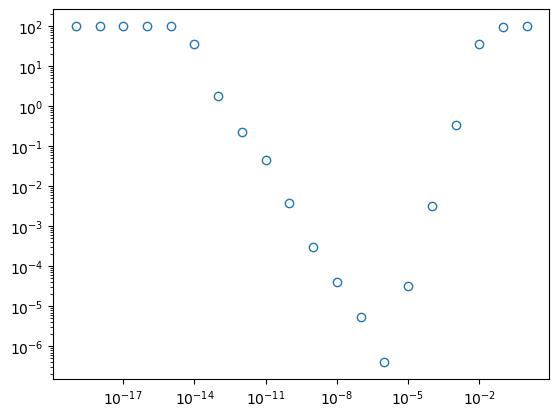

In [11]:
stepsizes = []

for i in range(20):
    stepsizes.append(10**(-i))

errorlist = []

for i in stepsizes:
    d = mid(f, 67, i)
    e = abs((d-g(67))/g(67))*100
    errorlist.append(e)

fig, ax = plt.subplots()

ax.loglog(stepsizes, errorlist, 'o', mfc='none')